# Phase 2: Trajectory Prediction with Auxiliary Depth Estimation

# 🧭 Introduction

"""
Welcome to **Phase 2** of the DLAV Projec! 🚗💨

In this phase, you'll work with a more challenging dataset that includes:
- RGB **camera images**
- Ground-truth **depth maps**
- Ground-truth **semantic segmentation** labels

Your goal is still to predict the **future trajectory** of the self-driving car (SDC), but you now have more tools at your disposal! 🎯

Here, we provide an example where **depth estimation** is used as an auxiliary task to improve trajectory prediction.

However, you're **free to explore** other auxiliary tasks (e.g., using semantic labels), different loss functions, data augmentations, or better architectures! 💡

This notebook will walk you through loading the dataset, building a model, training with and without the auxiliary task, and visualizing results.
"""

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# path_colab = "drive/MyDrive/Colab Notebooks/Phase_1/"
# # path_colab = ''

In [2]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=d7267fa3-57fc-4270-8881-0f14ded798c1
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:05<00:00, 74.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=2f45d0ef-4651-4676-90e2-6c2c6c8d4187
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:00<00:00, 128MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=b791be4d-253e-40f7-a87c-4eaac1534c3d
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:01<00:00, 43.8MB/s]


## 📂 The Dataset

We are now working with a richer dataset that includes not just images and trajectories,
but also **depth maps** (and semantic segmentation labels, though unused in this example).

The data is stored in `.pkl` files and each file contains:
- `camera`: RGB image (shape: H x W x 3)
- `sdc_history_feature`: the past trajectory of the car
- `sdc_future_feature`: the future trajectory to predict
- `depth`: ground truth depth map (shape: H x W x 1)

We'll define a `DrivingDataset` class to load and return these tensors in a format our model can work with.

In [199]:
import os
import torch
import pickle
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import csv
import random
from torchvision import transforms
from PIL import Image

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# resize the camera frame by adding rows to the top to make it square then resizing to 224x224 for ResNet
def camera_transform(image, img_mean: np.array, img_std: np.array):
  img_np = np.array(image)  # Shape: (200, 300, 3)

  # Step 1: Get average color of top row
  avg_color = img_np[0, :, :].mean(axis=0)  # (R, G, B), float64
  avg_color_uint8 = avg_color.astype(np.uint8)

  # Step 2: Pad at the top to make it 300x300
  pad_height = img_np.shape[1] - img_np.shape[0]  # 300 - 200 = 100
  padding = np.tile(avg_color_uint8, (pad_height, img_np.shape[1], 1))  # Shape: (100, 300, 3)

  # Step 3: Stack padding + original image
  padded_img = np.vstack((padding, img_np))  # Shape: (300, 300, 3)

  padded_img = Image.fromarray(padded_img)

  transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=img_mean,
        std=img_std
    )
  ])

  transformed_img = transform(padded_img)

  return(transformed_img)

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False):
        self.samples = file_list
        self.test = test

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        # camera = torch.FloatTensor(data['camera']).permute(2, 0, 1) / 255.0
        img_mean = np.array([151.3254/255, 151.6072/255, 151.6273/255])   # mean value of nuPlan img
        img_std = np.array([36.0859/255, 36.1013/255, 35.6058/255])       # std dev of nuPlan img
        camera = data['camera']
        camera = camera_transform(camera, img_mean, img_std)

        history = torch.FloatTensor(data['sdc_history_feature'])

        depth = torch.FloatTensor(data['depth'])

        # Semantic labels
        semantic_colormap = {
            0: [0, 0, 0],         # UNLABELED
            1: [0, 0, 142],       # CAR
            2: [0, 0, 70],        # TRUCK
            3: [220, 20, 60],     # PEDESTRIAN
            4: [119, 11, 32],     # BIKE
            5: [152, 251, 152],   # TERRAIN
            6: [128, 64, 128],    # ROAD
            7: [244, 35, 232],    # SIDEWALK
            8: [70, 130, 180],    # SKY
            9: [250, 170, 30],    # TRAFFIC_LIGHT
            10: [190, 153, 153],  # FENCE
            11: [220, 220, 0],    # TRAFFIC_SIGN
            12: [255, 255, 255],  # LANE_LINE
            13: [55, 176, 189],   # CROSSWALK
            14: [0, 60, 100]      # BUS
        }
        semantic_label = torch.FloatTensor(data['semantic_label'])
        height, width = semantic_label.shape
        rgb_semantic_img = torch.zeros((3, height, width), dtype=torch.float32)
        for label, color in semantic_colormap.items():
            for i in range(3):
                rgb_semantic_img[i][semantic_label == label] = color[i] / 255.0


        if not self.test:
            future = torch.FloatTensor(data['sdc_future_feature'])
            return {
                'camera': camera,
                'history': history,
                'depth': depth,
                'semantic_label': rgb_semantic_img,
                'future': future
            }
        else:
            return {
                'camera': camera,
                'history': history,
                'depth': depth,
                'semantic_label': rgb_semantic_img
            }

In [200]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import sys
import numpy as np

class Logger:
    def __init__(self, total_epochs):
        # Placeholder for potential future configs (e.g., log_dir, wandb_enabled, etc.)
        self.loss_val = []
        self.loss_tr  = []
        self.ade_val  = []
        self.fde_val  = []
        self.epoch    = []
        self.best_ade = 50
        self.total_epochs = total_epochs

    def log(self, epoch=None, **metrics):
        """
        Logs the given metrics.

        Args:
            step (int, optional): The current step or epoch. Useful for tracking.
            **metrics: Arbitrary keyword arguments representing metric names and values.
        """
        if epoch is not None:
            self.epoch.append(epoch+1)

        for key, val in metrics.items():
            if key == 'loss_val':
                self.loss_val.append(val)
            elif key == 'loss_tr':
                self.loss_tr.append(val)
            elif key == 'ADE':
                self.ade_val.append(val)
                if val < self.best_ade:
                  self.best_ade = val
            elif key == 'FDE':
                self.fde_val.append(val)

    def plot(self):
        # Create the subplots
        fig, axs = plt.subplots(1, 5, figsize=(25, 5))  # 1 row, 3 columns

        # 1st subplot: Plot 'a'
        axs[0].plot(self.epoch, self.loss_tr, marker='o', color='blue')
        axs[0].set_title("Training loss")
        axs[0].set_xlabel("Epoch")
        axs[0].set_ylabel("Loss [-]")
        axs[0].grid(True)

        # 2nd subplot: Plot 'b'
        axs[1].plot(self.epoch, self.loss_val, marker='x', color='red')
        axs[1].set_title("Validation Loss")
        axs[1].set_xlabel("Epoch")
        axs[1].set_ylabel("Loss [-]")
        axs[1].grid(True)

        # 3rd subplot: Plot 'c' and 'd'
        axs[2].plot(self.epoch, self.ade_val, marker='x', color='red')
        axs[2].set_title("Validation ADE")
        axs[2].set_xlabel("Epoch")
        axs[2].set_ylabel("Error [-]")
        axs[2].grid(True)

        # 4th subplot
        axs[3].plot(self.epoch, self.fde_val, marker='o', color='blue')
        axs[3].set_title("Validation FDE")
        axs[3].set_xlabel("Epoch")
        axs[3].set_ylabel("Error [-]")
        axs[3].grid(True)

        # 4th subplot
        axs[4].plot(self.epoch, np.array(self.loss_val) - np.array(self.loss_tr), marker='o', color='blue')
        axs[4].set_title("Loss Difference")
        axs[4].set_xlabel("Epoch")
        axs[4].set_ylabel("Val-Train loss [-]")
        axs[4].grid(True)

        fig.tight_layout()
        # Clear the previous plot only
        clear_output(wait=True)
        display(fig)  # Display the current figure

        # Close the figure to avoid duplication in Jupyter
        plt.close(fig)
    def clean(self):
        self.loss_val.pop(0)
        self.loss_tr.pop(0)
        self.ade_val.pop(0)
        self.fde_val.pop(0)
        self.epoch.pop(0)

    def printf(self):
        message = f'Epoch {self.epoch[-1]}/{self.total_epochs}'
        message += f' | Train Loss: {self.loss_tr[-1]:.4f}'
        message += f' | Val Loss: {self.loss_val[-1]:.4f}'
        message += f' | ADE: {self.ade_val[-1]:.4f}'
        message += f' | FDE: {self.fde_val[-1]:4f}'
        message += f' | Best ADE: {min(self.ade_val):.4f}'
        sys.stdout.write(f'\n {message}')
        sys.stdout.flush()

## 🧠 The Model: Trajectory + Depth Prediction

We've extended our trajectory prediction model to optionally include a **depth estimation decoder**.

Why?
- Predicting depth helps the model **learn richer visual features** from the camera input.
- This acts as a form of **multi-task learning**, where learning to estimate depth reinforces scene understanding, ultimately leading to better trajectory predictions.
- This can be especially useful in complex environments with occlusions or sharp turns.

The model has:
- A CNN backbone to extract features from the image
- An MLP to process historical trajectory features
- A trajectory decoder to predict future coordinates
- (Optionally) A depth decoder to predict dense depth maps

This auxiliary task is enabled by setting `use_depth_aux=True`.

In [201]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DrivingPlanner_basic(nn.Module):
    def __init__(self, use_depth_aux=False):
        super().__init__()
        self.use_depth_aux = use_depth_aux

        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU()
        )

        self.cnn_flatten = nn.Flatten()


        # Decoder for trajectory prediction
        self.decoder = nn.Linear((32 * 100 * 150) + (21 * 3), 60 * 3)

        # Optional depth decoder
        if self.use_depth_aux:
            self.depth_decoder = nn.Sequential(
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # Upsample
                nn.ReLU(),
                nn.Conv2d(16, 1, kernel_size=3, padding=1),
                nn.Upsample(size=(200, 300), mode='bilinear', align_corners=False)
            )

    def forward(self, camera, history):
        B = camera.size(0)

        # Process camera
        cnn_feat = self.cnn_backbone(camera)         # (B, 32, 100, 150)
        feat_flat = self.cnn_flatten(cnn_feat)       # (B, 32*100*150)


        # Flatten history
        history_flat = history.view(B, -1)

        # Concatenate and decode trajectory
        combined = torch.cat([feat_flat, history_flat], dim=1)
        future = self.decoder(combined).view(B, 60, 3)

        # Optional depth map prediction
        depth_out = None
        if self.use_depth_aux:
            depth_out = self.depth_decoder(cnn_feat.detach()).permute(0, 2, 3, 1)

        return future, depth_out


## 🏋️ Training with Auxiliary Loss

The training loop is similar to Phase 1 — except now, if enabled, we also compute a loss on the predicted **depth map**.

We define:
- `trajectory_loss` as standard MSE between predicted and true future trajectory
- `depth_loss` as L1 loss between predicted and ground truth depth

Total loss = `trajectory_loss + lambda * depth_loss`

This helps guide the model to learn better representations from visual input. The weight `lambda` is a hyperparameter you can tune!

In [202]:
import sys
from torch import nn
class customCriterion(nn.Module):
  def __init__(self, x_scale = 1.0, y_scale = 1.0, heading_scale = 4.0):
    super(customCriterion, self).__init__()
    self.x_scale = x_scale
    self.y_scale = y_scale
    self.heading_scale = heading_scale

  def forward(self, predictions, target):
    x_error = predictions[:, :, 0] - target[:, :, 0]
    y_error = predictions[:, :, 1] - target[:, :, 1]
    heading_error = predictions[:, :, 2] - target[:, :, 2]
    loss = (self.x_scale * x_error**2 +
              self.y_scale * y_error**2 +
              self.heading_scale * heading_error**2).mean()
    return loss

In [233]:
import torch
import torch.nn.functional as F

def train_one_epoch(model,
                    train_loader,
                    optimizer,
                    device,
                    logger,
                    epoch,
                    lambda_depth=0.1,
                    lambda_semantic=0.1,
                    use_depth_aux=False,
                    use_semantic_aux=False):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        cam, hist, fut, dep, sem = [batch[k].to(device) for k in ['camera', 'history', 'future', 'depth', 'semantic_label']]
        optimizer.zero_grad()
        fut_pred, dep_pred, sem_pred = model(cam, hist)

        traj_loss = F.mse_loss(fut_pred, fut)
        loss = traj_loss
        if use_depth_aux:
            loss += lambda_depth * F.l1_loss(dep_pred, dep)
        if use_semantic_aux:
            loss += lambda_semantic * F.l1_loss(sem_pred, sem)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)
    logger.log(epoch=epoch, loss_tr=avg_loss)
    return

def validate(model,
             val_loader,
             device,
             logger,
             epoch=None):
    model.eval()
    total_ade, total_fde, total_mse = 0.0, 0.0, 0.0
    count = 0

    with torch.no_grad():
        for batch in val_loader:
            cam = batch['camera'].to(device)
            hist = batch['history'].to(device)
            fut = batch['future'].to(device)

            fut_pred, _, _ = model(cam, hist)

            B, T, _ = fut.shape
            count += B

            ade = torch.norm(fut_pred[:, :, :2] - fut[:, :, :2], dim=2).mean(dim=1).sum()
            fde = torch.norm(fut_pred[:, -1, :2] - fut[:, -1, :2], dim=1).sum()
            mse = F.mse_loss(fut_pred, fut, reduction='sum')

            total_ade += ade.item()
            total_fde += fde.item()
            total_mse += mse.item()

    ade_avg = total_ade / count
    fde_avg = total_fde / count
    mse_avg = total_mse / (count * T * 3)

    if epoch is not None:
      logger.log(ADE=ade_avg, FDE=fde_avg, loss_val=mse_avg)

    return

def train(model,
          train_loader,
          val_loader,
          optimizer,
          logger,
          num_epochs=50,
          start_epoch=0,
          lambda_depth=0.1,
          lambda_semantic=0.1,
          use_depth_aux=False,
          use_semantic_aux=False,
          scheduler=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model = model.to(device)

    for epoch in range(num_epochs):
        train_one_epoch(model,
                        train_loader,
                        optimizer,
                        device,
                        logger,
                        epoch,
                        lambda_depth,
                        lambda_semantic,
                        use_depth_aux,
                        use_semantic_aux)
        validate(model, val_loader, device, logger, epoch)
        logger.plot()
        logger.printf()
        if epoch == 0 and start_epoch == 0:
            logger.clean()
        if scheduler is not None:
            scheduler.step()

In [234]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
val_data_dir = "val"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files = [os.path.join(val_data_dir, f) for f in os.listdir(val_data_dir) if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files)
val_dataset = DrivingDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)


## 🔍 Let's Compare Two Settings

We'll now train and evaluate the model in **two modes**:

1. **Without auxiliary task** — the model only predicts the trajectory.
2. **With depth auxiliary task** — the model also predicts a depth map, which helps it learn better visual features.

By comparing the results (ADE, FDE, and Trajectory MSE), you'll see the benefit of multi-task learning in action! 🚀

In [235]:
import torch
import torch.nn as nn
from torchvision import models


class DrivingPlanner(nn.Module):
    def __init__(self, use_depth_aux=False, use_semantic_aux=False): # Changed _init to _init_
        super().__init__()
        self.use_depth_aux = use_depth_aux
        self.use_semantic_aux = use_semantic_aux

        # Load pretrained ResNet
        resnet = models.resnet34(pretrained=True)

        # Freeze all resnet parameters
        for param in resnet.parameters():
            param.requires_grad = False

        # Use all resnet layers up to (but not including) avgpool
        self.img_encoder_L1 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,  # 56 x 56 x 64
        )
        self.img_encoder_L2 = resnet.layer2 # 28 x 28 x 128
        self.img_encoder_L3 = resnet.layer3 # 14 x 14 x 256
        self.img_encoder_L4 = resnet.layer4 # Output: 7x7x512

        # Use Resnet
        self.resnet = nn.Sequential(
            resnet.avgpool,
            nn.Flatten(),  # Output: batchx512
            nn.Linear(512, 256)
        )

        # Encoder for the history
        self.history_encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*21, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )

        # Decoder for predicting future trajectory
        self.future_decoder = nn.Sequential(
            nn.ReLU(),
            nn.Linear(256 + 128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 60 * 3)
        )

        # Decoder for Depth estimation
        if self.use_depth_aux:
            self.depth_L3 = self._upsample_block(512, 256)       # 14 x 14   x 256
            self.depth_L2 = self._upsample_block(256 + 256, 128) # 28 x 28   x 128
            self.depth_L1 = self._upsample_block(128 + 128, 64)  # 56 x 56   x 64
            self.depth_decoder = nn.Sequential(
                self._upsample_block(64 + 64, 32),    # 112 x 112 x 32
                self._upsample_block(32, 16),         # 224 x 224 x 16
                nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),  # 224x224 -> 448x448
                nn.ReLU(inplace=True),
                nn.Conv2d(8, 1, kernel_size=3, padding=1),  # 448 x 448 x 1
            )

        if self.use_semantic_aux:
            self.semantic_L3 = self._upsample_block(512, 256)       # 14 x 14   x 256
            self.semantic_L2 = self._upsample_block(256 + 256, 128) # 28 x 28   x 128
            self.semantic_L1 = self._upsample_block(128 + 128, 64)  # 56 x 56   x 64
            self.semantic_decoder = nn.Sequential(
                self._upsample_block(64 + 64, 32),    # 112 x 112 x 32
                self._upsample_block(32, 16),         # 224 x 224 x 16
                nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),  # 224x224 -> 448x448
                nn.ReLU(inplace=True),
                nn.Conv2d(8, 3, kernel_size=3, padding=1),  # 448 x 448 x 3
            )

    def _upsample_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, camera, history):
        # Process camera images
        img_encoder_L1 = self.img_encoder_L1(camera)
        img_encoder_L2 = self.img_encoder_L2(img_encoder_L1)
        img_encoder_L3 = self.img_encoder_L3(img_encoder_L2)
        visual_features = self.img_encoder_L4(img_encoder_L3)
        visual_resnet   = self.resnet(visual_features)

        # Process History
        history = self.history_encoder(history)

        # Predict future
        combined = torch.cat([visual_resnet, history], dim=1)
        future = self.future_decoder(combined)
        future = future.reshape(-1, 60, 3)  # Reshape to (batch_size, timesteps, features)

        # Predict depth
        if self.use_depth_aux:
            depth_L3 = self.depth_L3(visual_features)
            depth_L2 = self.depth_L2(torch.cat([depth_L3, img_encoder_L3], dim=1))
            depth_L1 = self.depth_L1(torch.cat([depth_L2, img_encoder_L2], dim=1))
            depth_out = self.depth_decoder(torch.cat([depth_L1, img_encoder_L1], dim=1))
            depth_out = F.interpolate(depth_out, size=(300, 300), mode='area').permute(0, 2, 3, 1)
            depth_out = depth_out[:,:200, :300, :]

        # Predict semantic information
        if self.use_semantic_aux:
            semantic_L3 = self.semantic_L3(visual_features)
            semantic_L2 = self.semantic_L2(torch.cat([semantic_L3, img_encoder_L3], dim=1))
            semantic_L1 = self.semantic_L1(torch.cat([semantic_L2, img_encoder_L2], dim=1))
            semantic_out = self.semantic_decoder(torch.cat([semantic_L1, img_encoder_L1], dim=1))
            semantic_out = F.interpolate(semantic_out, size=(300, 300), mode='area')#.permute(0, 2, 3, 1)
            semantic_out = semantic_out[:,:,:200, :300]

        # Voila
        if self.use_depth_aux and self.use_semantic_aux:
            return future, depth_out, semantic_out
        elif self.use_depth_aux:
            return future, depth_out, None
        elif self.use_semantic_aux:
            return future, None, semantic_out
        else:
            return future, None, None



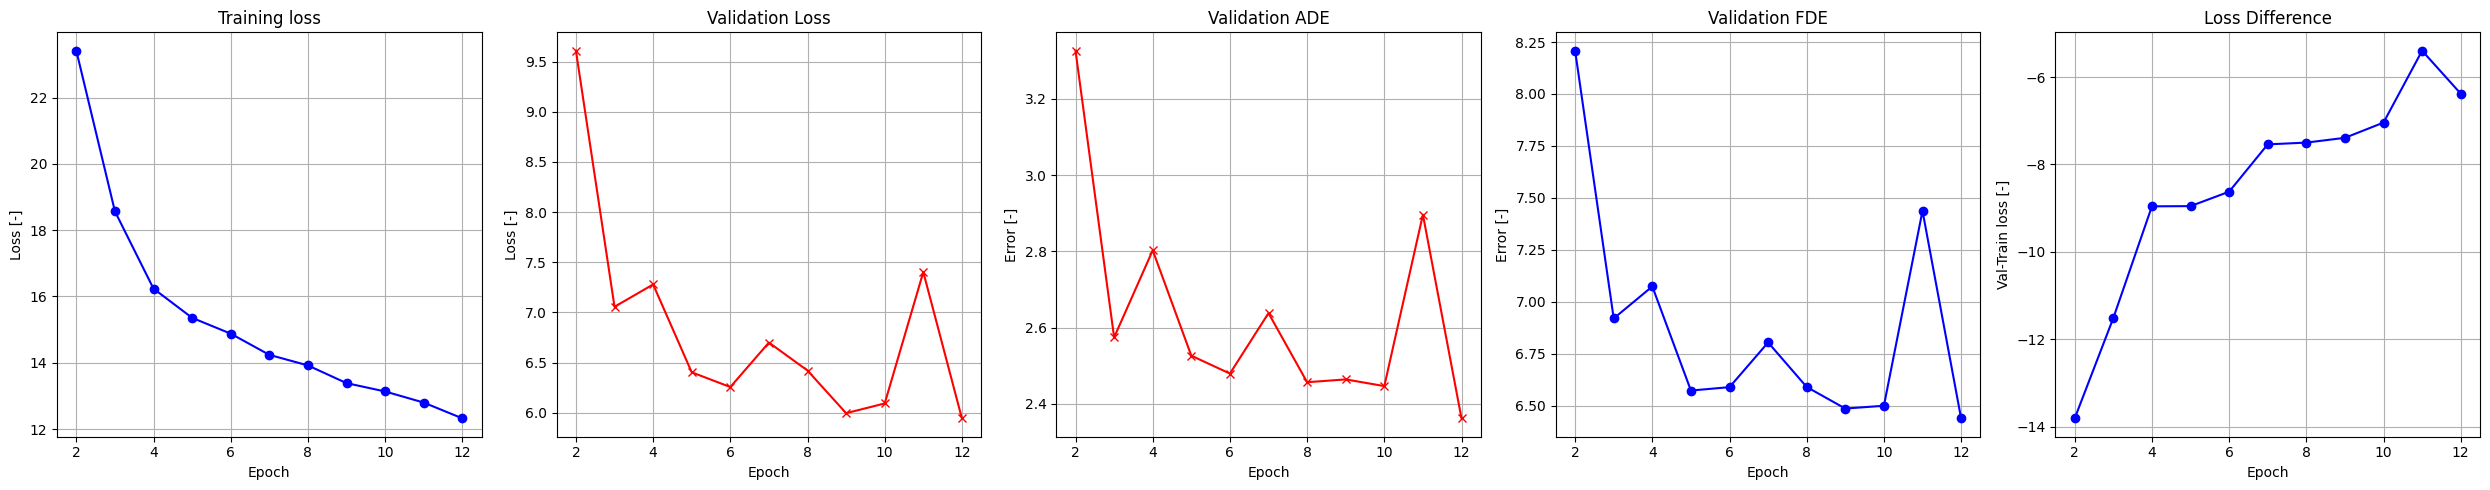


 Epoch 12/25 | Train Loss: 12.3229 | Val Loss: 5.9444 | ADE: 2.3623 | FDE: 6.439401 | Best ADE: 2.3623

KeyboardInterrupt: 

In [238]:
import torch.optim as optim
import time
import gc

# Clear GPU memory
if 'model' in globals():
    del globals()['model']
gc.collect()
torch.cuda.empty_cache()
time.sleep(4)

model = DrivingPlanner(use_depth_aux=False, use_semantic_aux=True)
tot_epochs = 25
logger = Logger(tot_epochs)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=tot_epochs, eta_min=1e-6)

train(model, train_loader, val_loader, optimizer,
      logger, num_epochs=tot_epochs, start_epoch=0,
      lambda_depth=0.75, lambda_semantic=0.75*255,
      use_depth_aux=False, use_semantic_aux=True,
      scheduler=scheduler)

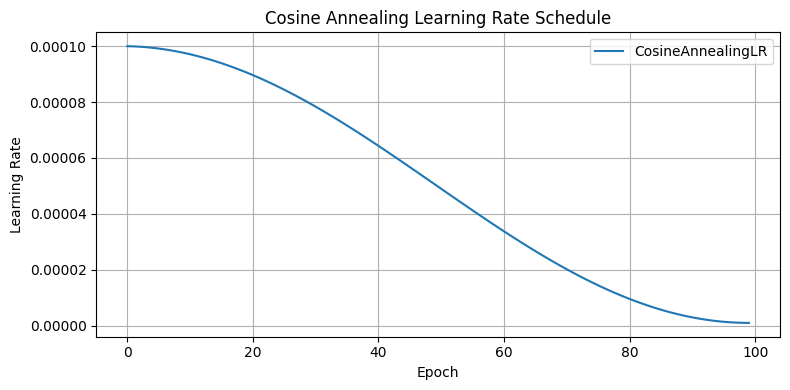

In [132]:
# Dummy model and optimizer
model2 = nn.Linear(10, 1)
optimizer = optim.Adam(model2.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler setup
tot_epochs = 100
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=tot_epochs, eta_min=1e-6, verbose=True)

# Record learning rates
lrs = []
for epoch in range(tot_epochs):
    optimizer.step()  # dummy step to simulate training
    scheduler.step()
    lrs.append(optimizer.param_groups[0]['lr'])

# Plot
plt.figure(figsize=(8, 4))
plt.plot(range(tot_epochs), lrs, label="CosineAnnealingLR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing Learning Rate Schedule")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 🔍 Final Visualization and Comparison

Now that we’ve trained two models — one **with** the depth auxiliary task and one **without** — let’s visualize and compare their predictions.

We’ll show:
1. The **camera image** from selected validation examples
2. The **past trajectory**, **ground-truth future**, and **predicted future** trajectory
3. The **predicted vs. ground-truth depth maps** (only for the model trained with the auxiliary task)

These visualizations help us understand:
- Does the predicted trajectory better match the future when the depth task is included?
- Is the predicted depth map reasonably accurate?

Let’s see the difference! 📈

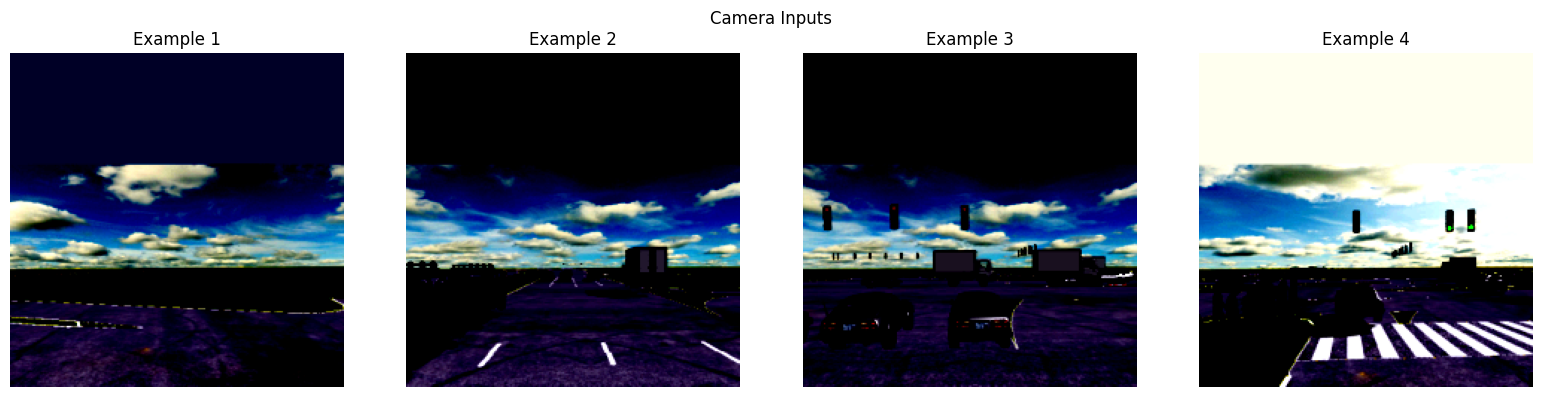

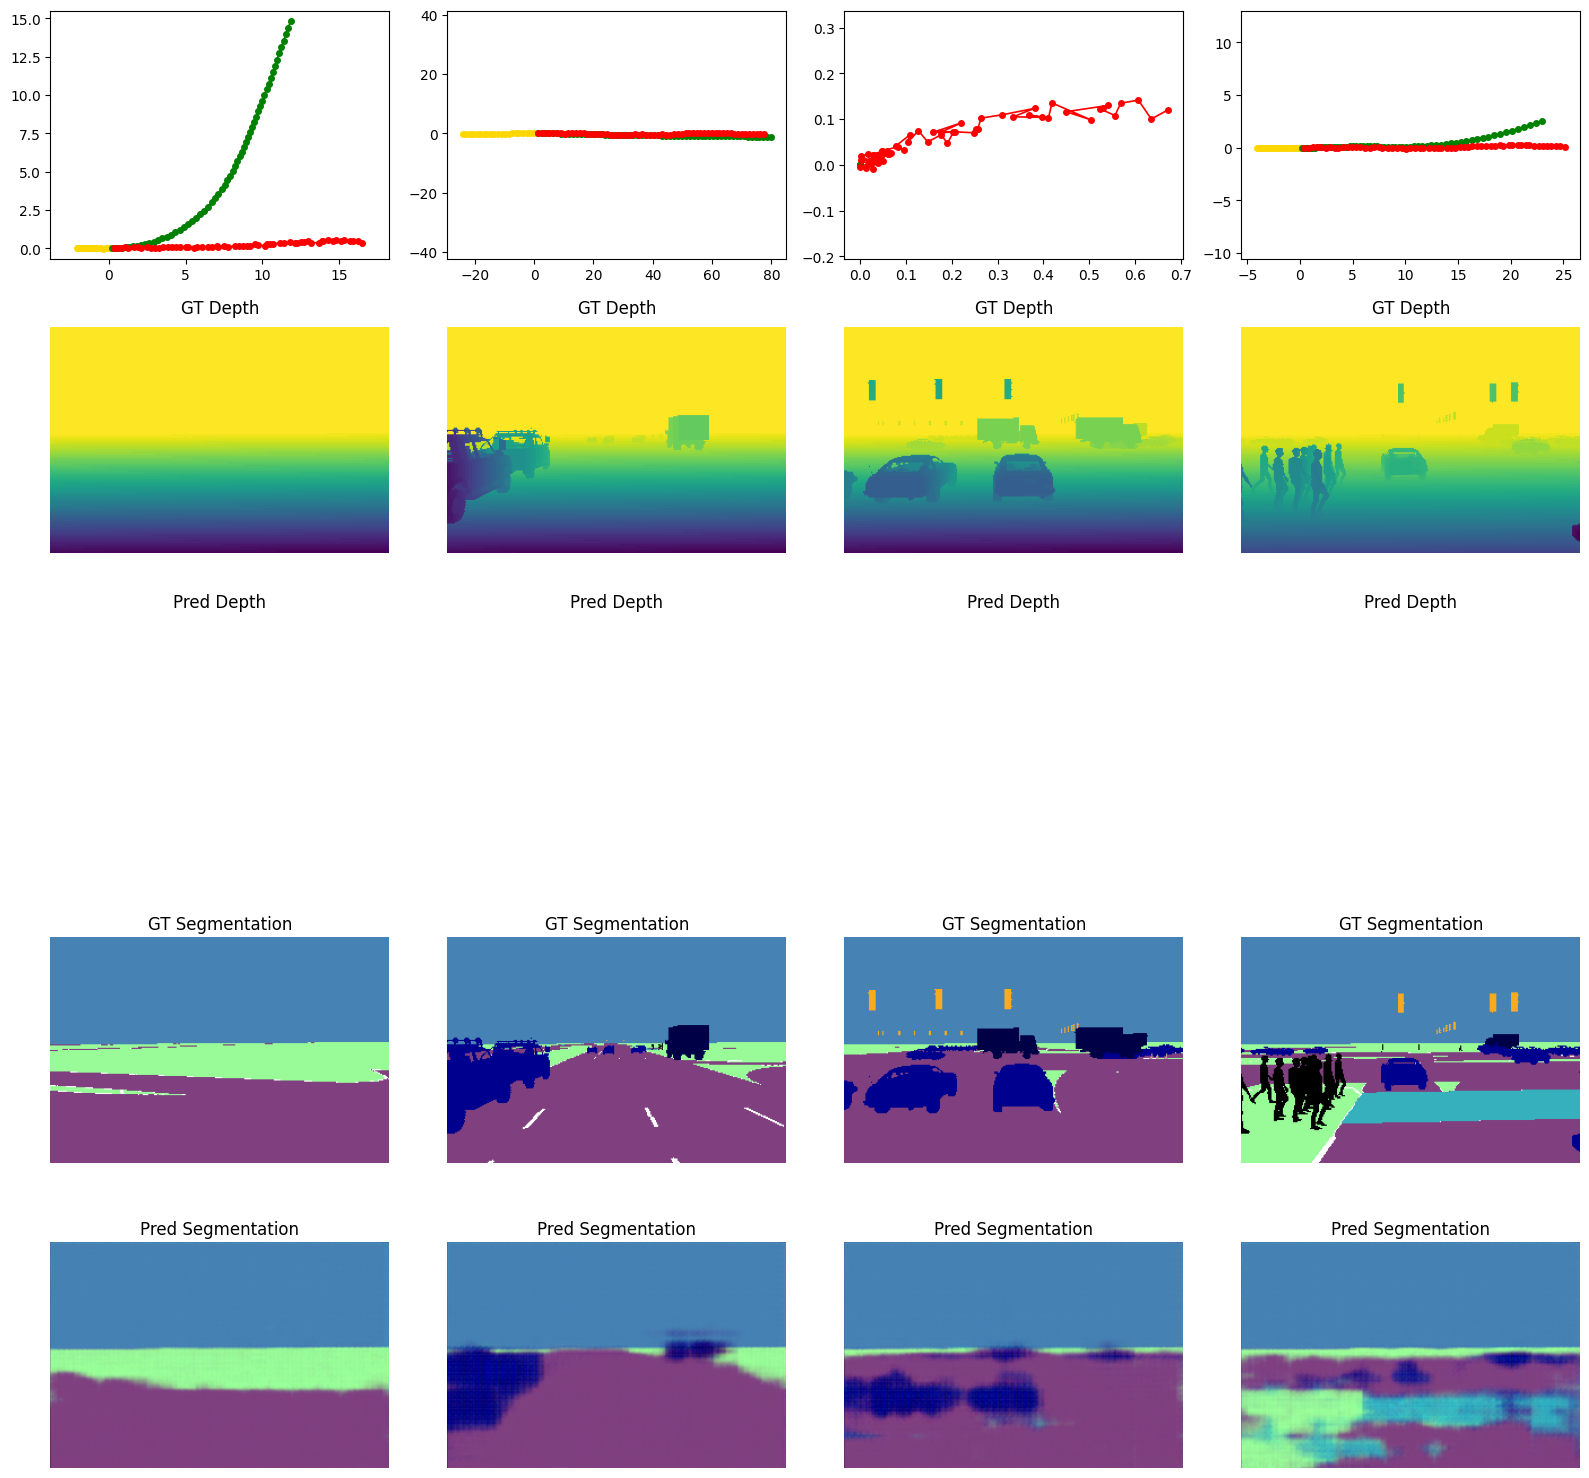

In [239]:
import matplotlib.pyplot as plt
import random

random.seed(25)

def visualize_with_depth(val_loader, model, device):
    model.eval()
    val_batch = next(iter(val_loader))

    camera = val_batch['camera'].to(device)
    history = val_batch['history'].to(device)
    future = val_batch['future'].to(device)
    depth = val_batch['depth'].to(device)
    sem_gt = val_batch['semantic_label'].to(device)

    with torch.no_grad():
        pred_future, pred_depth, pred_sem = model(camera, history)

    camera = camera.cpu().numpy()
    history = history.cpu().numpy()
    future = future.cpu().numpy()
    pred_future = pred_future.cpu().numpy()
    depth = depth.cpu().numpy()
    pred_depth = pred_depth.cpu().numpy() if pred_depth is not None else None
    semantic_gt = sem_gt.cpu().numpy()
    pred_semantic = pred_sem.cpu().numpy() if pred_sem is not None else None

    k = 4
    indices = random.choices(np.arange(len(camera)), k=k)

    # Show the input camera images
    fig, ax = plt.subplots(1, k, figsize=(4 * k, 4))
    for i, idx in enumerate(indices):
        ax[i].imshow(camera[idx].transpose(1, 2, 0))
        ax[i].set_title(f"Example {i+1}")
        ax[i].axis("off")
    plt.suptitle("Camera Inputs")
    plt.tight_layout()
    plt.show()

    # Compare predicted trajectories
    fig, ax = plt.subplots(5, k, figsize=(4 * k, 3*5))
    for i, idx in enumerate(indices):
        # Trajectory prediction
        ax[0, i].plot(history[idx, :, 0], history[idx, :, 1], 'o-', label='Past', color='gold', markersize=4, linewidth=1.2)
        ax[0, i].plot(future[idx, :, 0], future[idx, :, 1], 'o-', label='GT Future', color='green', markersize=4, linewidth=1.2)
        ax[0, i].plot(pred_future[idx, :, 0], pred_future[idx, :, 1], 'o-', label='Pred (Future)', color='red', markersize=4, linewidth=1.2)
        ax[0, i].axis("equal")

        # Depth True
        ax[1, i].imshow(depth[idx, :, :, 0], cmap='viridis')
        ax[1, i].set_title("GT Depth", pad=10)
        ax[1, i].axis("off")

        # Depth Pred
        if pred_depth is not None:
            ax[2, i].imshow(pred_depth[idx, :, :, 0], cmap='viridis')
        ax[2, i].set_title("Pred Depth", pad=10)
        ax[2, i].axis("off")

        # Plot semantic image
        ax[3, i].imshow(semantic_gt[idx].transpose(1,2,0))
        ax[3, i].set_title(f"GT Segmentation")
        ax[3, i].axis("off")

        # semantic predicted
        if pred_semantic is not None:
            ax[4, i].imshow(pred_semantic[idx].transpose(1,2,0))
        ax[4, i].set_title(f"Pred Segmentation")
        ax[4, i].axis("off")

    plt.tight_layout()
    plt.show()

# 🔚 Call at the end after training both models
visualize_with_depth(val_loader, model, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called submission_phase2.csv by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

In [ ]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

dict_keys(['camera', 'depth', 'driving_command', 'sdc_history_feature', 'semantic_label'])


In [ ]:
import pandas as pd
test_data_dir = "test_public"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]
test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)
model_with_aux.eval()
all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)

        pred_future, _ = model_with_aux(camera, history)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv("submission_phase2.csv", index=False)

print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (1000, 121)
